<a href="https://colab.research.google.com/github/AditiSinghal28/Machine-Learning-Projects/blob/ml/Gold_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING THE DEPENDENCIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

DATA COLLECTION AND PROCESSING

In [2]:
# loading dataset into pandas dataframe
gold_data = pd.read_csv('/content/gld_price_data.csv')

In [3]:
gold_data.shape

(2290, 6)

In [4]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
# print last five rows of dataset
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [6]:
# getting some basic info about the data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [7]:
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [8]:
# getting the statistical analysis of the dataframe
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


CORRELATION


1.   POSITIVE CORRELATION
2.   NEGATIVE CORRELATION



In [11]:
 #dropping the date column bc some entries are in string format and its producing error as they cant be changed to float
 correlation = gold_data.drop(['Date'],axis=1).corr()

<Axes: >

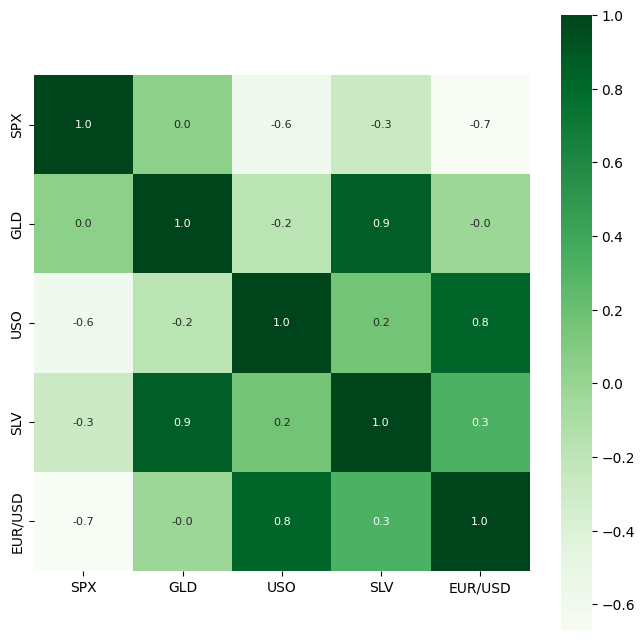

In [17]:
# constructing a heatmap to understand correlation
plt.figure(figsize=(8,8))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Greens')

In [19]:
# correlation values of gold (GLD)
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


<ipython-input-20-b13bd63c2226>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

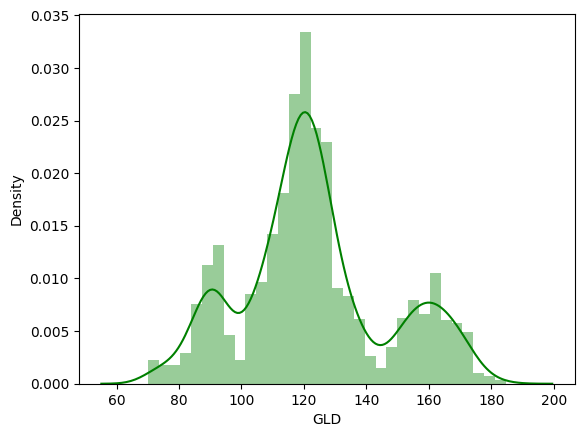

In [20]:
# distribution of GLD values
sns.distplot(gold_data['GLD'],color='green')

In [21]:
# splitting the data and labels
X = gold_data.drop(['GLD', 'Date'],axis=1)
Y = gold_data['GLD']

In [22]:
print(X)
print(Y)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]
0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


SPLITTING THE DATA INTO TRAINING AND TEST DATA

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [24]:
print(X.shape, X_train.shape, X_test.shape)

(2290, 4) (1832, 4) (458, 4)


MODEL TRAINING -


*   RANDOM FOREST REGRESSOR



In [25]:
regressor = RandomForestRegressor(n_estimators=100) #the number of decision trees in the forest.
# default value is 100

In [26]:
# training the model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

MODEL EVALUATION

In [27]:
# prediction on test data
test_data_prediction = regressor.predict(X_test)

In [28]:
print(test_data_prediction)

[168.47399963  82.01799994 116.19100015 127.67570068 120.68510129
 154.73569743 150.18299815 126.03270021 117.59039872 125.99480079
 116.72520088 171.88590088 141.24309862 167.89729869 115.31859975
 117.49480051 138.4199034  169.71730079 160.1923035  158.51219974
 154.95339988 125.27720025 176.15410029 156.7557036  125.25290029
  93.77819971  77.37819971 120.66899972 119.06109898 167.38599989
  88.20990036 125.21969978  91.02710039 117.76920012 121.17699902
 136.3528008  115.20360138 114.96950084 146.95829924 107.05010105
 104.20890241  87.09569796 126.39890075 118.04410022 154.59059922
 119.33470042 108.25439992 107.99039845  93.07800055 127.09199792
  74.55960044 113.70449929 121.22070025 111.24909902 118.97939922
 120.60429958 158.24000083 165.47600157 147.07609677  85.83269877
  94.34920049  86.97749915  90.59540005 119.05700089 126.37880071
 127.49770017 169.14650014 122.27709969 117.11739933  98.30500015
 168.32770086 143.04319815 133.48160221 121.37700223 121.50059924
 119.73350

In [29]:
# R SQUARED ERROR FOR ACCURACY PREDICTION
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error : ", error_score)

R squared error :  0.9891972506002543


COMPARE THE ACTUAL AND PREDICTED VALUES

In [30]:
# converting y_test to a list
Y_test = list(Y_test)

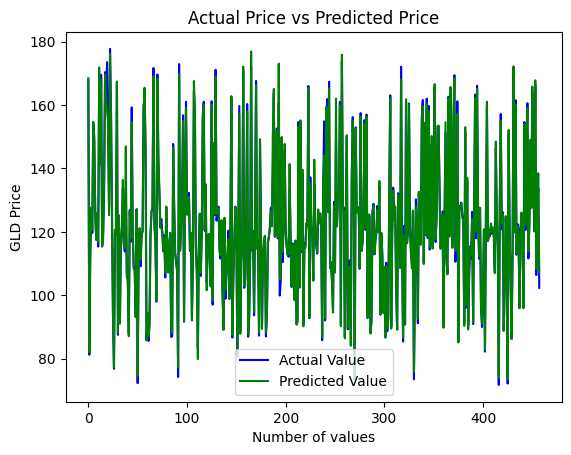

In [32]:
plt.plot(Y_test, color = 'blue', label = 'Actual Value')
plt.plot(test_data_prediction, color = 'green', label = 'Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()